Importamos librerias

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pandas.tseries.offsets import DateOffset

Copia de librerias de ETSFormer y parchamos para que use GPU

In [ ]:
# 1. Borramos la carpeta vieja por si acaso y descargamos una versión limpia
!rm -rf Time-Series-Library
!git clone https://github.com/thuml/Time-Series-Library.git

# 2. Aplicamos el parche de forma segura (idempotente)
file_path = './Time-Series-Library/layers/ETSformer_EncDec.py'

with open(file_path, 'r') as f:
    code = f.read()

old_line = "f = repeat(f, 'f -> b f d', b=x_freq.size(0), d=x_freq.size(2))"
new_line = "f = repeat(f, 'f -> b f d', b=x_freq.size(0), d=x_freq.size(2)).to(x_freq.device)"

# Solo parcheamos si no está parcheado ya
if old_line in code and new_line not in code:
    code = code.replace(old_line, new_line)
    with open(file_path, 'w') as f:
        f.write(code)
    print("✅ ¡Bug de la librería parcheado exitosamente!")
else:
    print("✅ El archivo ya estaba correcto.")

Cloning into 'Time-Series-Library'...
remote: Enumerating objects: 2251, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 2251 (delta 24), reused 17 (delta 17), pack-reused 2209 (from 2)
Receiving objects: 100% (2251/2251), 78.41 MiB | 32.35 MiB/s, done.
Resolving deltas: 100% (1536/1536), done.
✅ ¡Bug de la librería parcheado exitosamente!


Descargamos los archivos de las series de horas y minutos

In [ ]:
import os
import urllib.request

# Lista con las URLs crudas (raw) oficiales de los 4 archivos
urls =[
    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv',
    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv',
    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv',
    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv'
]

print("Iniciando la revisión y descarga de los datasets ETT...")

for url in urls:
    # Extrae el nombre final del archivo de la URL (ej. 'ETTh1.csv')
    filename = url.split('/')[-1]

    # Verificamos si el archivo ya existe en tu Colab
    if not os.path.exists(filename):
        print(f"⬇️ Descargando {filename} por primera vez... (Esto puede tomar unos segundos)")
        urllib.request.urlretrieve(url, filename)
        print(f"✅ {filename} descargado exitosamente.")
    else:
        print(f"✔️ {filename} ya existe en el entorno. Omitiendo descarga para ahorrar tiempo.")

print("\n🚀 ¡Los 4 archivos (ETTh1, ETTh2, ETTm1, ETTm2) están listos para usarse!")

Iniciando la revisión y descarga de los datasets ETT...
✔️ ETTh1.csv ya existe en el entorno. Omitiendo descarga para ahorrar tiempo.
✔️ ETTh2.csv ya existe en el entorno. Omitiendo descarga para ahorrar tiempo.
✔️ ETTm1.csv ya existe en el entorno. Omitiendo descarga para ahorrar tiempo.
✔️ ETTm2.csv ya existe en el entorno. Omitiendo descarga para ahorrar tiempo.

🚀 ¡Los 4 archivos (ETTh1, ETTh2, ETTm1, ETTm2) están listos para usarse!


Función de estandarización

In [ ]:
class StandardScaler:
    def __init__(self, mean, std, eps=1e-6):
        self.mean = mean.astype(np.float32)
        self.std = np.where(std < eps, eps, std).astype(np.float32)
        self.eps = eps

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse_transform(self, x):
        return x * self.std + self.mean

Funcion para calculo de medidas

In [ ]:
# Calcular las medias y desviaciones por archivo
def make_scalers(train_segments, feature_cols):
    scalers = []
    for i, seg in enumerate(train_segments):
        tr   = seg[feature_cols].dropna()
        mean = tr.mean(axis=0).to_numpy(dtype=np.float32)   # orden = feature_cols
        std  = tr.std(axis=0, ddof=0).to_numpy(dtype=np.float32)
        scalers.append(StandardScaler(mean, std))
    return scalers

Creación del dataset

In [ ]:
class ETTDataset(Dataset):
    def __init__(
        self,
        segments, # Lista de segmentos temporales (deberian ser dos)
        seq_len=96,
        pred_len=96,
        target_col="OT",
        feature_cols=None,
        scalers=None, # Creamos un Scaler por archivo (son dos)
        split_name="train", # "train", "val", "test"
    ):
        if feature_cols is None:
            feature_cols = list(segments[0].columns)

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_col = target_col
        self.feature_cols = feature_cols
        self.split_name = split_name

        self.series_data = []
        self.scalers = scalers
        self.index_map = []
        self.target_idx = self.feature_cols.index(self.target_col)

        # Preparar los datos
        for sidx, seg in enumerate(segments):
            seg = seg.sort_index()
            miss = [c for c in self.feature_cols if c not in seg.columns]
            if miss:
                raise ValueError(f"Serie {sidx}: faltan columnas {miss}.")

            seg = seg[self.feature_cols].copy().dropna()

            scaler = self.scalers[sidx]
            X_all = scaler.transform(seg.to_numpy(dtype=np.float32))  # [n_seq, n_features]
            y_all = X_all[:, self.target_idx]                         # [n_seq]

            T = X_all.shape[0]
            max_start = T - (self.seq_len + self.pred_len)
            if max_start < 0:
                # No alcanza para la ventana
                starts = np.array([], dtype=np.int64)
            else:
                starts = np.arange(0, max_start + 1, dtype=np.int64)

            self.series_data.append({"X": X_all, "y": y_all, "starts": starts})

        # Indice
        for sidx in (0, 1):
            for st in self.series_data[sidx]["starts"]:
                self.index_map.append((sidx, int(st)))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        sidx, st = self.index_map[idx]
        X_all = self.series_data[sidx]["X"]
        y_all = self.series_data[sidx]["y"]

        x = X_all[st : st + self.seq_len, :]
        y = y_all[st + self.seq_len : st + self.seq_len + self.pred_len]

        x = torch.from_numpy(x).float()
        y = torch.from_numpy(y).float().unsqueeze(-1)
        series_id = torch.tensor(sidx, dtype=torch.long)

        return x, y, series_id

Función para leer el CSV

In [ ]:
def read_ETT_csv(path):
    df = pd.read_csv(path)
    if "date" not in df.columns:
        raise ValueError(f"{path} no tiene columna 'date'.")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True).set_index("date")
    return df

Función para dividir la data

In [ ]:
def split_TrainValTest(df):
    start = df.index.min()
    train_end = start + DateOffset(months=12)
    val_end   = train_end + DateOffset(months=4)
    test_end  = val_end + DateOffset(months=4)
    return (
        df.loc[(df.index >= start) & (df.index < train_end)].copy(),
        df.loc[(df.index >= train_end) & (df.index < val_end)].copy(),
        df.loc[(df.index >= val_end) & (df.index < test_end)].copy(),
    )

Función para generar la data con la división necesaria

In [ ]:
def make_DataLoader(df0, df1, in_horizon, out_horizon, features, n_batch=64):
    df0_train, df0_val, df0_test = split_TrainValTest(df0)
    df1_train, df1_val, df1_test = split_TrainValTest(df1)

    scalers = make_scalers([df0_train, df1_train], features)

    trainDataset = ETTDataset([df0_train, df1_train],
                              seq_len=in_horizon, pred_len=out_horizon,
                              target_col="OT", feature_cols=features,
                              scalers=scalers, split_name="train")

    valDataset   = ETTDataset([df0_val, df1_val], seq_len=in_horizon,
                              pred_len=out_horizon,
                              target_col="OT", feature_cols=features,
                              scalers=scalers, split_name="val")

    testDataset  = ETTDataset([df0_test, df1_test], seq_len=in_horizon,
                              pred_len=out_horizon,
                              target_col="OT", feature_cols=features,
                              scalers=scalers, split_name="test")

    trainLoader = DataLoader(trainDataset, batch_size=n_batch, shuffle=True, drop_last=True)
    valLoader   = DataLoader(valDataset, batch_size=n_batch, shuffle=False)
    testLoader  = DataLoader(testDataset, batch_size=n_batch, shuffle=False)

    return trainLoader, valLoader, testLoader

Importar o definir el Modelo ETSformer

In [ ]:
import sys
import torch
import torch.nn as nn

# Agregamos la carpeta clonada al sistema para poder importar sus archivos
if './Time-Series-Library' not in sys.path:
    sys.path.append('./Time-Series-Library')

# Importamos el modelo oficial
from models.ETSformer import Model as Original_ETSformer

class ETSformer_Wrapper(nn.Module):
    def __init__(self, seq_len, pred_len, device, freq='h'):
        super(ETSformer_Wrapper, self).__init__()

        # Configuraciones del modelo
        class Config:
            def __init__(self, s_len, p_len, frequency):
                self.task_name = 'long_term_forecast'
                self.seq_len = s_len
                self.label_len = s_len // 2
                self.pred_len = p_len
                self.enc_in = 7
                self.dec_in = 7
                self.c_out = 1
                self.d_model = 512
                self.n_heads = 4

                self.e_layers = 2
                self.d_layers = 2

                self.d_ff = 512
                self.dropout = 0.1
                self.embed = 'timeF'

                self.freq = frequency # <--- Frecuencia dinámica ('h' o 't')

                self.activation = 'sigmoid'
                self.output_attention = False
                self.top_k = 5
                self.num_kernels = 6

        self.configs = Config(seq_len, pred_len, freq)
        self.device = device

        # Instanciamos la red neuronal real
        self.model = Original_ETSformer(self.configs).to(device)

    def forward(self, x):
        batch_size = x.shape[0]

        # ==========================================
        # CORRECCIÓN CLAVE: Determinar dimensiones según frecuencia
        # 'h' espera 4 columnas de tiempo, 't' espera 5 columnas
        # ==========================================
        num_time_features = 5 if self.configs.freq == 't' else 4

        # 1. Marcas de tiempo (Time Stamps vacías pero con el tamaño correcto)
        x_mark = torch.zeros(batch_size, self.configs.seq_len, num_time_features).to(self.device)

        # 2. Input del Decoder (Requisito de la arquitectura)
        dec_inp = torch.zeros(batch_size, self.configs.pred_len, x.shape[-1]).to(self.device)
        dec_inp = torch.cat([x[:, -self.configs.label_len:, :], dec_inp], dim=1)
        dec_mark = torch.zeros(batch_size, dec_inp.shape[1], num_time_features).to(self.device)

        # 3. Pase hacia adelante (Forward Pass)
        out = self.model(x, x_mark, dec_inp, dec_mark)

        return out

Funciones de Entrenamiento y Evaluación en PyTorch

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y, _ in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        # Predicción
        outputs = model(batch_x)

        # Calcular pérdida (MSE)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_mae = 0.0

    mae_criterion = nn.L1Loss() # MAE

    with torch.no_grad():
        for batch_x, batch_y, _ in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(outputs, batch_y) # MSE
            mae = mae_criterion(outputs, batch_y) # MAE

            total_loss += loss.item()
            total_mae += mae.item()

    return total_loss / len(dataloader), total_mae / len(dataloader)

Ciclo Principal (Iterando por los horizontes)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# Parámetros del Laboratorio
input_horizon = 96
horizons_to_evaluate =[24, 48, 96, 192, 336, 720]
feature_cols =["HUFL","HULL","MUFL","MULL","LUFL","LULL","OT"]
#epochs = 5 # Ajusta este valor (ideal entre 10 y 20 para resultados reales)
epochs = 5 # Ajusta este valor (ideal entre 10 y 20 para resultados reales)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# ==========================================
# CORRECCIÓN: Cargar los datos a la memoria antes de usarlos
# ==========================================
print("Cargando archivos CSV en memoria...")
try:
    df0_h = read_ETT_csv("ETTh1.csv")
    df1_h = read_ETT_csv("ETTh2.csv")
    print("¡Archivos cargados con éxito!")
except FileNotFoundError:
    print("ERROR: No se encontraron los archivos ETTh1.csv o ETTh2.csv en la carpeta actual.")

# Diccionarios para guardar resultados finales
test_mse_results = {}
test_mae_results = {}
history_dict = {} # Para guardar las curvas de aprendizaje

for out_horizon in horizons_to_evaluate:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo para Horizonte de Predicción: {out_horizon}")
    print(f"{'='*50}")

    # 1. Crear los DataLoaders para ESTE horizonte
    trainLoader, valLoader, testLoader = make_DataLoader(
        df0_h, df1_h, input_horizon, out_horizon, feature_cols, n_batch=64
    )

    # 2. Instanciar el modelo (Usando el Wrapper que definimos en la Celda 1)
    #model = ETSformer_Wrapper(seq_len=input_horizon, pred_len=out_horizon).to(device)
    model = ETSformer_Wrapper(seq_len=input_horizon, pred_len=out_horizon, device=device, freq='h')

    # 3. Optimizador y Función de Pérdida
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # Historial de métricas
    train_losses, val_losses = [],[]

    # 4. Bucle de Épocas
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, trainLoader, optimizer, criterion, device)
        val_loss, val_mae = evaluate(model, valLoader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

    # 5. Evaluación final en Test (Usando el mejor modelo de la última época)
    test_loss, test_mae = evaluate(model, testLoader, criterion, device)
    print(f">>> TEST FINAL H={out_horizon} | Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

    # Guardar resultados para la gráfica
    test_mse_results[out_horizon] = test_loss
    test_mae_results[out_horizon] = test_mae
    history_dict[out_horizon] = {'train': train_losses, 'val': val_losses}

Entrenando en: cuda
Cargando archivos CSV en memoria...
¡Archivos cargados con éxito!

Entrenando modelo para Horizonte de Predicción: 24


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 24, 1])) that is different to the input size (torch.Size([64, 24, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([64, 24, 1])) that is different to the input size (torch.Size([64, 24, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, targe

Epoch 1/5 | Train MSE: 0.8234 | Val MSE: 0.3634 | Val MAE: 0.4483
Epoch 2/5 | Train MSE: 0.3641 | Val MSE: 0.2695 | Val MAE: 0.4012
Epoch 3/5 | Train MSE: 0.3082 | Val MSE: 0.2150 | Val MAE: 0.3450
Epoch 4/5 | Train MSE: 0.2797 | Val MSE: 0.2396 | Val MAE: 0.3757
Epoch 5/5 | Train MSE: 0.2544 | Val MSE: 0.2494 | Val MAE: 0.3833


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([18, 24, 1])) that is different to the input size (torch.Size([18, 24, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([18, 24, 1])) that is different to the input size (torch.Size([18, 24, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 48, 1])) that is different to the input size (torch.Size([64, 48, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same 

>>> TEST FINAL H=24 | Test MSE: 0.2618 | Test MAE: 0.4198

Entrenando modelo para Horizonte de Predicción: 48


...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([34, 336, 1])) that is different to the input size (torch.Size([34, 336, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([34, 336, 1])) that is different to the input size (torch.Size([34, 336, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


>>> TEST FINAL H=336 | Test MSE: 0.6593 | Test MAE: 0.6634

Entrenando modelo para Horizonte de Predicción: 720


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 720, 1])) that is different to the input size (torch.Size([64, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([64, 720, 1])) that is different to the input size (torch.Size([64, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([50, 720, 1])) that is different to the input size (torch.Size([50, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the

Epoch 1/5 | Train MSE: 0.8302 | Val MSE: 0.6258 | Val MAE: 0.6065
Epoch 2/5 | Train MSE: 0.4711 | Val MSE: 0.5103 | Val MAE: 0.5373
Epoch 3/5 | Train MSE: 0.4045 | Val MSE: 0.5221 | Val MAE: 0.5399
Epoch 4/5 | Train MSE: 0.3736 | Val MSE: 0.4778 | Val MAE: 0.5138
Epoch 5/5 | Train MSE: 0.3580 | Val MSE: 0.4602 | Val MAE: 0.5110
>>> TEST FINAL H=720 | Test MSE: 0.5740 | Test MAE: 0.6363


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([34, 720, 1])) that is different to the input size (torch.Size([34, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([34, 720, 1])) that is different to the input size (torch.Size([34, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Reporte Final de Resultados y Gráficas de Entrenamiento (horas)


=== REPORTE FINAL DE MÉTRICAS (ETTh) ===


,Horizonte,Test MSE,Test MAE
0,24,0.261788,0.419797
1,48,0.347945,0.478029
2,96,0.666915,0.710874
3,192,0.252987,0.398966
4,336,0.659260,0.663386
5,720,0.573986,0.636311


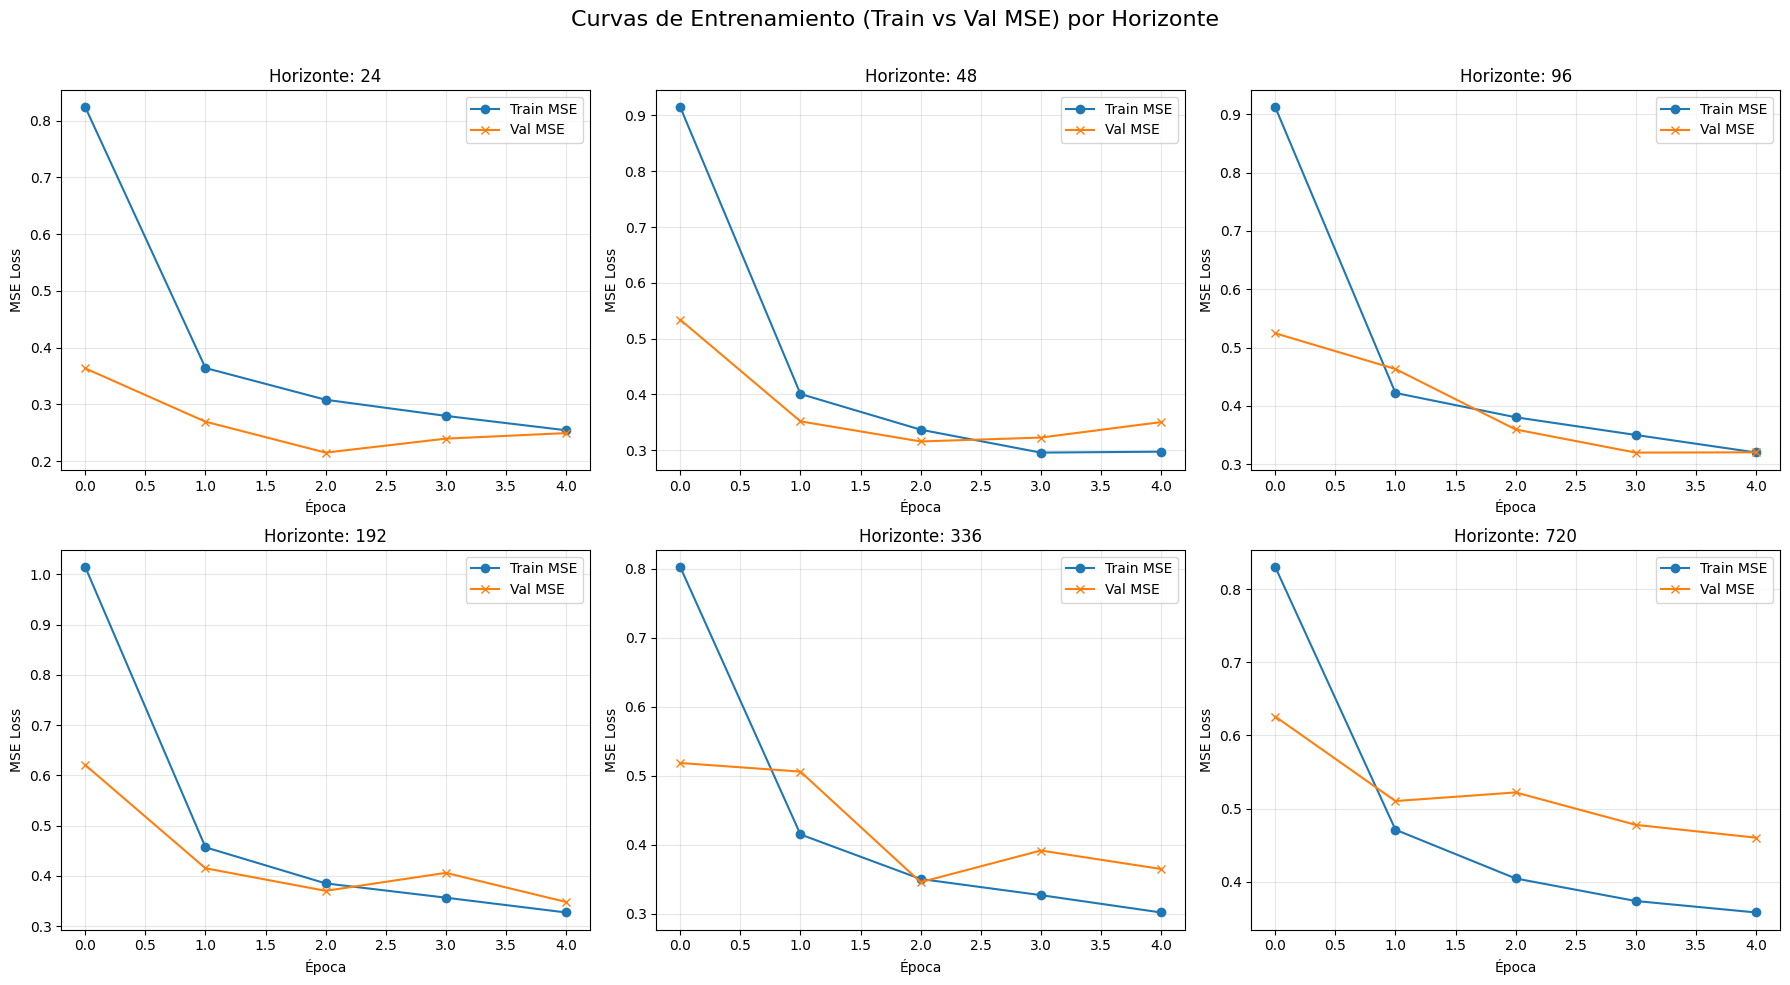

In [ ]:
# 1. Mostrar Tabla de Resultados (DataFrame)
reporte_df = pd.DataFrame({
    'Horizonte': horizons_to_evaluate,
    'Test MSE': [test_mse_results[h] for h in horizons_to_evaluate],
    'Test MAE': [test_mae_results[h] for h in horizons_to_evaluate]
})

print("\n=== REPORTE FINAL DE MÉTRICAS (ETTh) ===")
display(reporte_df)

# 2. Gráficas de las curvas de entrenamiento (Loss curves)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Curvas de Entrenamiento (Train vs Val MSE) por Horizonte', fontsize=16)

axes = axes.flatten()

for idx, h in enumerate(horizons_to_evaluate):
    ax = axes[idx]
    ax.plot(history_dict[h]['train'], label='Train MSE', marker='o')
    ax.plot(history_dict[h]['val'], label='Val MSE', marker='x')
    ax.set_title(f'Horizonte: {h}')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

Archivos de minutos

In [ ]:
# ==========================================
# CICLO DE ENTRENAMIENTO PARA MINUTOS (ETTm)
# ==========================================
print("Cargando archivos CSV de MINUTOS en memoria...")
df0_m = read_ETT_csv("ETTm1.csv")
df1_m = read_ETT_csv("ETTm2.csv")
print("¡Archivos ETTm cargados con éxito!")

# Diccionarios para guardar resultados finales de minutos
test_mse_m = {}
test_mae_m = {}
history_m = {}

for out_horizon in horizons_to_evaluate:
    print(f"\n{'='*50}")
    print(f"Entrenando ETTm (Minutos) | Horizonte: {out_horizon}")
    print(f"{'='*50}")

    # 1. Crear los DataLoaders (usamos df0_m y df1_m)
    trainLoader, valLoader, testLoader = make_DataLoader(
        df0_m, df1_m, input_horizon, out_horizon, feature_cols, n_batch=64
    )

    # 2. Instanciar el modelo PASÁNDOLE freq='t' (minutos)
    model = ETSformer_Wrapper(seq_len=input_horizon, pred_len=out_horizon, device=device, freq='t')

    # 3. Optimizador y Función de Pérdida
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses, val_losses = [],[]

    # 4. Bucle de Épocas
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, trainLoader, optimizer, criterion, device)
        val_loss, val_mae = evaluate(model, valLoader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

    # 5. Evaluación final en Test
    test_loss, test_mae = evaluate(model, testLoader, criterion, device)
    print(f">>> TEST FINAL ETTm H={out_horizon} | Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

    # Guardar resultados
    test_mse_m[out_horizon] = test_loss
    test_mae_m[out_horizon] = test_mae
    history_m[out_horizon] = {'train': train_losses, 'val': val_losses}

Cargando archivos CSV de MINUTOS en memoria...
¡Archivos ETTm cargados con éxito!

Entrenando ETTm (Minutos) | Horizonte: 24


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 24, 1])) that is different to the input size (torch.Size([64, 24, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([64, 24, 1])) that is different to the input size (torch.Size([64, 24, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([18, 24, 1])) that is different to the input size (torch.Size([18, 24, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same 

Epoch 1/5 | Train MSE: 0.3559 | Val MSE: 0.1696 | Val MAE: 0.3105
Epoch 2/5 | Train MSE: 0.1802 | Val MSE: 0.2090 | Val MAE: 0.3664
Epoch 3/5 | Train MSE: 0.1624 | Val MSE: 0.1132 | Val MAE: 0.2593
Epoch 4/5 | Train MSE: 0.1493 | Val MSE: 0.0969 | Val MAE: 0.2336
Epoch 5/5 | Train MSE: 0.1435 | Val MSE: 0.1086 | Val MAE: 0.2514
>>> TEST FINAL ETTm H=24 | Test MSE: 0.0691 | Test MAE: 0.2016

Entrenando ETTm (Minutos) | Horizonte: 48


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 48, 1])) that is different to the input size (torch.Size([64, 48, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([64, 48, 1])) that is different to the input size (torch.Size([64, 48, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([34, 48, 1])) that is different to the input size (torch.Size([34, 48, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same 

Epoch 1/5 | Train MSE: 0.3630 | Val MSE: 0.1722 | Val MAE: 0.3182
Epoch 2/5 | Train MSE: 0.1965 | Val MSE: 0.1498 | Val MAE: 0.2941
Epoch 3/5 | Train MSE: 0.1799 | Val MSE: 0.1264 | Val MAE: 0.2770
Epoch 4/5 | Train MSE: 0.1674 | Val MSE: 0.1315 | Val MAE: 0.2804
Epoch 5/5 | Train MSE: 0.1608 | Val MSE: 0.1715 | Val MAE: 0.3248
>>> TEST FINAL ETTm H=48 | Test MSE: 0.1222 | Test MAE: 0.2783

Entrenando ETTm (Minutos) | Horizonte: 96


...

Epoch 1/5 | Train MSE: 0.4143 | Val MSE: 0.2780 | Val MAE: 0.4093
Epoch 2/5 | Train MSE: 0.2477 | Val MSE: 0.2527 | Val MAE: 0.3978
Epoch 3/5 | Train MSE: 0.2273 | Val MSE: 0.2289 | Val MAE: 0.3732
Epoch 4/5 | Train MSE: 0.2214 | Val MSE: 0.2574 | Val MAE: 0.3948
Epoch 5/5 | Train MSE: 0.2070 | Val MSE: 0.2798 | Val MAE: 0.4127
>>> TEST FINAL ETTm H=192 | Test MSE: 0.1416 | Test MAE: 0.2911

Entrenando ETTm (Minutos) | Horizonte: 336


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 336, 1])) that is different to the input size (torch.Size([64, 336, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([64, 336, 1])) that is different to the input size (torch.Size([64, 336, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([34, 336, 1])) that is different to the input size (torch.Size([34, 336, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the

Epoch 1/5 | Train MSE: 0.4381 | Val MSE: 0.3224 | Val MAE: 0.4389
Epoch 2/5 | Train MSE: 0.2638 | Val MSE: 0.3083 | Val MAE: 0.4315
Epoch 3/5 | Train MSE: 0.2487 | Val MSE: 0.3076 | Val MAE: 0.4330
Epoch 4/5 | Train MSE: 0.2371 | Val MSE: 0.3069 | Val MAE: 0.4352
Epoch 5/5 | Train MSE: 0.2315 | Val MSE: 0.2957 | Val MAE: 0.4277
>>> TEST FINAL ETTm H=336 | Test MSE: 0.4463 | Test MAE: 0.5825

Entrenando ETTm (Minutos) | Horizonte: 720


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 720, 1])) that is different to the input size (torch.Size([64, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([64, 720, 1])) that is different to the input size (torch.Size([64, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([34, 720, 1])) that is different to the input size (torch.Size([34, 720, 7])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the

Epoch 1/5 | Train MSE: 0.5019 | Val MSE: 0.6888 | Val MAE: 0.6420
Epoch 2/5 | Train MSE: 0.3078 | Val MSE: 0.4366 | Val MAE: 0.5156
Epoch 3/5 | Train MSE: 0.2811 | Val MSE: 0.3642 | Val MAE: 0.4852
Epoch 4/5 | Train MSE: 0.2723 | Val MSE: 0.3064 | Val MAE: 0.4463
Epoch 5/5 | Train MSE: 0.2644 | Val MSE: 0.4441 | Val MAE: 0.5258
>>> TEST FINAL ETTm H=720 | Test MSE: 0.9039 | Test MAE: 0.7946


Reporte Final de Resultados y Gráficas de Entrenamiento (Minutos)


=== REPORTE FINAL DE MÉTRICAS ETTm (MINUTOS) ===


,Horizonte,Test MSE,Test MAE
0,24,0.069109,0.201555
1,48,0.122235,0.278263
2,96,0.142312,0.299936
3,192,0.141641,0.291121
4,336,0.446262,0.582472
5,720,0.903874,0.794645


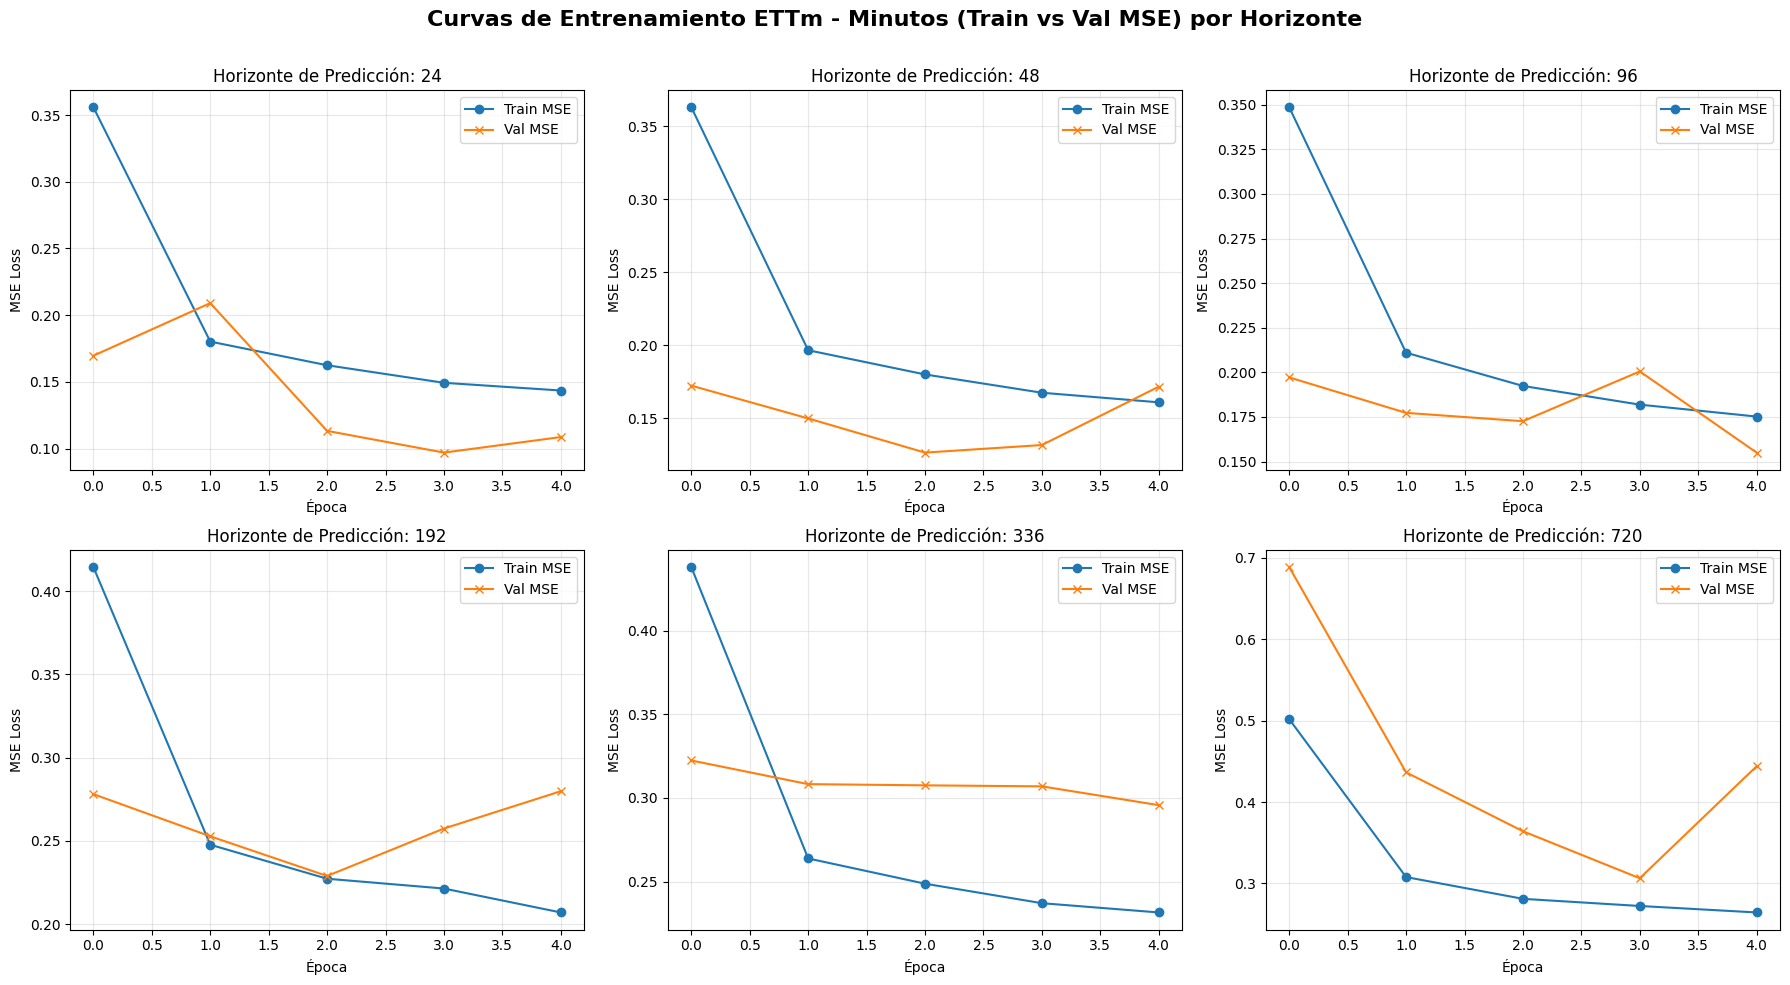

In [ ]:
# ==========================================
# REPORTE Y GRÁFICAS PARA MINUTOS (ETTm)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Mostrar Tabla de Resultados (DataFrame)
reporte_m_df = pd.DataFrame({
    'Horizonte': horizons_to_evaluate,
    'Test MSE': [test_mse_m[h] for h in horizons_to_evaluate],
    'Test MAE': [test_mae_m[h] for h in horizons_to_evaluate]
})

print("\n=== REPORTE FINAL DE MÉTRICAS ETTm (MINUTOS) ===")
display(reporte_m_df)

# 2. Gráficas de las curvas de entrenamiento (Loss curves)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Curvas de Entrenamiento ETTm - Minutos (Train vs Val MSE) por Horizonte', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, h in enumerate(horizons_to_evaluate):
    ax = axes[idx]
    # Usamos history_m en lugar de history_dict
    ax.plot(history_m[h]['train'], label='Train MSE', marker='o', color='#1f77b4')
    ax.plot(history_m[h]['val'], label='Val MSE', marker='x', color='#ff7f0e')
    ax.set_title(f'Horizonte de Predicción: {h}')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

Guardando resultados

In [ ]:
import os
import shutil
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================
# GUARDAR RESULTADOS Y DESCARGAR ENTREGABLE
# ==========================================

# 1. Crear una carpeta principal para el entregable
carpeta_salida = 'Resultados_Laboratorio_ETSformer'
os.makedirs(carpeta_salida, exist_ok=True)

# 2. Guardar las tablas de métricas como archivos CSV
reporte_df.to_csv(f'{carpeta_salida}/Metricas_ETTh_Horas.csv', index=False)
reporte_m_df.to_csv(f'{carpeta_salida}/Metricas_ETTm_Minutos.csv', index=False)
print("✅ Archivos CSV guardados correctamente.")

# 3. Regenerar y guardar la gráfica de HORAS en alta calidad (300 dpi)
fig_h, axes_h = plt.subplots(2, 3, figsize=(18, 10))
fig_h.suptitle('Curvas de Entrenamiento ETTh - Horas (Train vs Val MSE)', fontsize=16, fontweight='bold')
axes_h = axes_h.flatten()
for idx, h in enumerate(horizons_to_evaluate):
    ax = axes_h[idx]
    ax.plot(history_dict[h]['train'], label='Train MSE', marker='o', color='#1f77b4')
    ax.plot(history_dict[h]['val'], label='Val MSE', marker='x', color='#ff7f0e')
    ax.set_title(f'Horizonte: {h}')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# Guardar la imagen en la carpeta
fig_h.savefig(f'{carpeta_salida}/Graficas_Entrenamiento_ETTh_Horas.png', dpi=300, bbox_inches='tight')
plt.close(fig_h) # Cerramos la figura para no duplicarla en la pantalla
print("✅ Gráfica de Horas guardada en PNG (Alta calidad).")

# 4. Regenerar y guardar la gráfica de MINUTOS en alta calidad (300 dpi)
fig_m, axes_m = plt.subplots(2, 3, figsize=(18, 10))
fig_m.suptitle('Curvas de Entrenamiento ETTm - Minutos (Train vs Val MSE)', fontsize=16, fontweight='bold')
axes_m = axes_m.flatten()
for idx, h in enumerate(horizons_to_evaluate):
    ax = axes_m[idx]
    ax.plot(history_m[h]['train'], label='Train MSE', marker='o', color='#1f77b4')
    ax.plot(history_m[h]['val'], label='Val MSE', marker='x', color='#ff7f0e')
    ax.set_title(f'Horizonte: {h}')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# Guardar la imagen en la carpeta
fig_m.savefig(f'{carpeta_salida}/Graficas_Entrenamiento_ETTm_Minutos.png', dpi=300, bbox_inches='tight')
plt.close(fig_m)
print("✅ Gráfica de Minutos guardada en PNG (Alta calidad).")

# 5. Comprimir la carpeta en un archivo ZIP
archivo_zip = 'Entregable_Laboratorio_ETSformer'
shutil.make_archive(archivo_zip, 'zip', carpeta_salida)
print(f"\n📦 Carpeta comprimida en: {archivo_zip}.zip")

# 6. Descargar el archivo ZIP automáticamente a tu PC local
print("⬇️ Iniciando descarga...")
files.download(f'{archivo_zip}.zip')

✅ Archivos CSV guardados correctamente.
✅ Gráfica de Horas guardada en PNG (Alta calidad).
✅ Gráfica de Minutos guardada en PNG (Alta calidad).

📦 Carpeta comprimida en: Entregable_Laboratorio_ETSformer.zip
⬇️ Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>